# CSC2611 — Analysis
**Input:** interaction data collected from a hackathon.

Analysis:
1. Hierarchical topic modelling (LDA level 1 + 2) with pyLDAvis
2. Temporal network construction
3. Transition matrices
4. Spearman rank correlation on sentiment trajectory
---

In [4]:
import random, json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

In [5]:
df = pd.read_csv('cleaned_interactions.csv')
print(f'Shape: {df.shape}')
print(f'Windows: {sorted(df["window"].unique())}')
print(f'Columns: {list(df.columns)}')

Shape: (130, 15)
Windows: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Columns: ['idx', 'window', 'sender', 'receiver', 'reach_type', 'text', 'task_type', 'sentiment_score', 'sentiment_label', 'team', 'activity', 'channel', 'message', 'question', 'answer']


In [6]:
# Basic distributions
print('--- Reach type ---')
print(df['reach_type'].value_counts())
print()
print('--- Task type ---')
print(df['task_type'].value_counts())
print()
print('--- Sentiment label ---')
print(df['sentiment_label'].value_counts())

--- Reach type ---
reach_type
individual task              55
human-human collaboration    47
human-llm collaboration      28
Name: count, dtype: int64

--- Task type ---
task_type
coding       78
planning     22
debugging    21
deploying     9
Name: count, dtype: int64

--- Sentiment label ---
sentiment_label
positive    107
negative     21
neutral       2
Name: count, dtype: int64


## 1. Hierarchical topic modelling

### Level 1 — global topics across the full corpus

First build a vocabulary from all interaction texts using `CountVectorizer`, then fit a
single LDA model to extract global parent topics. Every interaction gets assigned its
dominant global topic.

In [7]:
N_GLOBAL_TOPICS = 4
N_SUB_TOPICS    = 2

all_texts = df['text'].fillna('').astype(str).tolist()

# Build vocabulary
vectorizer = CountVectorizer(
    stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z]{3,}\b',
    min_df=1,
    max_features=400
)
X_all = vectorizer.fit_transform(all_texts)
vocab = vectorizer.get_feature_names_out()

print(f'Vocabulary size: {len(vocab)}')
print(f'Document-term matrix: {X_all.shape}')

Vocabulary size: 400
Document-term matrix: (130, 400)


Vocabulary size: 400
Document-term matrix: (130, 400)

Global topic perplexity by K:
  K=2: 333.5
  K=3: 366.3
  K=4: 398.6
  K=5: 420.5
  K=6: 415.6
  K=7: 441.9
  K=8: 440.0
  K=9: 455.2  ← selected
  K=10: 502.3

Auto-selected N_GLOBAL_TOPICS = 9


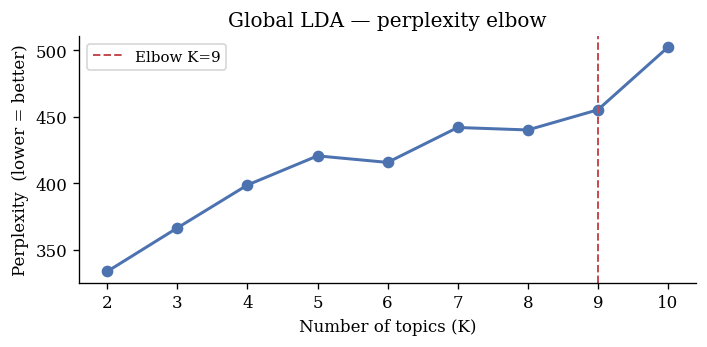

In [8]:
all_texts = df['text'].fillna('').astype(str).tolist()

vectorizer = CountVectorizer(
    stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z]{3,}\b',
    min_df=1,
    max_features=400
)
X_all = vectorizer.fit_transform(all_texts)
vocab = vectorizer.get_feature_names_out()

print(f'Vocabulary size: {len(vocab)}')
print(f'Document-term matrix: {X_all.shape}')

#Automatic K selection via perplexity elbow
def fit_lda(X, k, seed=SEED):
    m = LatentDirichletAllocation(
        n_components=k, random_state=seed,
        max_iter=30, learning_method='batch'
    )
    m.fit(X)
    return m

def elbow_k(X, k_range, seed=SEED):
    """
    Fit LDA for each k in k_range, compute perplexity, and return the k at
    the elbow of the curve using the kneedle method (max distance from the
    diagonal connecting first and last point).

    Also returns the full (ks, perplexities) arrays for plotting.
    """
    ks, perps = [], []
    for k in k_range:
        if k >= X.shape[0]:          # can't have more topics than documents
            break
        m = fit_lda(X, k, seed)
        ks.append(k)
        perps.append(m.perplexity(X))

    ks    = np.array(ks,    dtype=float)
    perps = np.array(perps, dtype=float)

    # Normalise both axes to [0, 1] so scale doesn't bias the distance
    x_n = (ks    - ks[0])    / (ks[-1]    - ks[0]    + 1e-10)
    y_n = (perps - perps[0]) / (perps[-1] - perps[0] + 1e-10)

    # For a decreasing curve the elbow is where x_n - y_n is maximised
    best_idx = int(np.argmax(x_n - y_n))
    return int(ks[best_idx]), ks.astype(int).tolist(), perps.tolist()

K_RANGE_GLOBAL = range(2, min(11, len(all_texts)))
N_GLOBAL_TOPICS, _ks_g, _perps_g = elbow_k(X_all, K_RANGE_GLOBAL)

print(f'\nGlobal topic perplexity by K:')
for k, p in zip(_ks_g, _perps_g):
    marker = '  ← selected' if k == N_GLOBAL_TOPICS else ''
    print(f'  K={k}: {p:.1f}{marker}')
print(f'\nAuto-selected N_GLOBAL_TOPICS = {N_GLOBAL_TOPICS}')

# ── Plot perplexity curve ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(_ks_g, _perps_g, marker='o', color='#4C72B0', linewidth=1.8)
ax.axvline(N_GLOBAL_TOPICS, color='#C44E52', linestyle='--', linewidth=1.2,
           label=f'Elbow K={N_GLOBAL_TOPICS}')
ax.set_xlabel('Number of topics (K)')
ax.set_ylabel('Perplexity  (lower = better)')
ax.set_title('Global LDA — perplexity elbow')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_global_elbow.png', bbox_inches='tight')
plt.show()

### Level-1 LDA — pyLDAvis interactive visualisation

pyLDAvis shows each topic as a bubble (size = prevalence) on a 2D inter-topic distance map
(computed via multidimensional scaling on Jensen-Shannon divergence between topic distributions).
The right panel shows the most relevant terms for a selected topic.

In [9]:
# Fit level-1 global LDA with the auto-selected K
global_lda       = fit_lda(X_all, N_GLOBAL_TOPICS)
global_doc_topic = global_lda.transform(X_all)

df['global_topic'] = np.argmax(global_doc_topic, axis=1).astype(int)

print(f'=== Level-1 global topics  (K={N_GLOBAL_TOPICS}, auto-selected) ===')
for t in range(N_GLOBAL_TOPICS):
    top_idx  = global_lda.components_[t].argsort()[-10:][::-1]
    keywords = [str(vocab[i]) for i in top_idx]
    print(f'  Topic {t}: {" | ".join(keywords)}')

print()
print('Global topic distribution across interactions:')
print(df['global_topic'].value_counts().sort_index())

=== Level-1 global topics  (K=9, auto-selected) ===
  Topic 0: commit | layout | recipe | component | navbar | query | card | added | recipes | image
  Topic 1: deployment | error | vercel | render | local | route | demo | working | openai | router
  Topic 2: vercel | profile | update | error | app | loading | recipe | commit | dall | express
  Topic 3: really | final | today | reflection | genuinely | solid | team | personalized | personalization | dev
  Topic 4: setup | added | folder | structure | created | express | conflict | grid | homepage | package
  Topic 5: render | vercel | query | express | use | app | page | add | api | env
  Topic 6: openai | added | env | recipes | rate | endpoint | limiting | merge | ready | commit
  Topic 7: recipe | query | user | openai | api | dark | add | added | prompt | dietary
  Topic 8: backend | endpoints | merge | let | frontend | working | branch | locally | route | tested

Global topic distribution across interactions:
global_topic
0    14


### Level 2 — sub-topics per (global topic × window)

For each combination of global topic and time window, we take the subset of documents belonging to that global topic in that window, and fit a smaller LDA to extract child sub-topics.

This gives us a two-level hierarchy:
- **Level 1:** stable global themes across the whole hackathon
- **Level 2:** how each theme is expressed differently at different points in time

Sub-topics are labelled `G{global}-S{sub}` (e.g. `G2-S1` = global topic 2, sub-topic 1).

In [10]:
topic_tree = {}
sub_labels = [''] * len(df)

for g in range(N_GLOBAL_TOPICS):
    g_mask = df['global_topic'] == g
    topic_tree[g] = {'N_sub': None, 'windows': {}}
    g_cluster = df[g_mask]

    # ── Auto-select N_SUB_TOPICS for this global topic cluster ────────────────
    g_texts  = g_cluster['text'].fillna('').astype(str).tolist()
    X_g      = vectorizer.transform(g_texts)
    max_sub  = min(6, len(g_texts) - 1)   # never more topics than documents - 1

    if max_sub < 2:
        # Cluster too small for sub-division — keep it as a single sub-topic
        N_sub = 1
        print(f'Global topic {g}: only {len(g_texts)} docs — using N_sub=1')
    else:
        K_RANGE_SUB        = range(2, max_sub + 1)
        N_sub, _ks_s, _perps_s = elbow_k(X_g, K_RANGE_SUB)
        print(f'Global topic {g} ({len(g_texts)} docs): '
              f'sub-topic perplexities {dict(zip(_ks_s, [round(p,1) for p in _perps_s]))} '
              f'→ N_sub={N_sub}')

    topic_tree[g]['N_sub'] = N_sub

    # ── Fit sub-topics per window within this global topic ────────────────────
    for w in sorted(df['window'].unique()):
        w_mask  = df['window'] == w
        cluster = df[g_mask & w_mask]
        if len(cluster) == 0:
            continue

        sub_texts = cluster['text'].fillna('').astype(str).tolist()
        X_sub     = vectorizer.transform(sub_texts)

        # Cap sub-topics to what the window cluster can support
        n_sub_w = max(1, min(N_sub, len(cluster) - 1))

        if n_sub_w < 2:
            # Only one feasible sub-topic — assign all to sub-topic 0
            for orig_idx in cluster.index:
                sub_labels[orig_idx] = f'G{g}-S0'
            topic_tree[g]['windows'][int(w)] = {
                0: [str(vocab[i])
                    for i in global_lda.components_[g].argsort()[-8:][::-1]]
            }
            continue

        sub_lda       = fit_lda(X_sub, n_sub_w)
        sub_doc_topic = sub_lda.transform(X_sub)
        dominant_sub  = np.argmax(sub_doc_topic, axis=1).astype(int)

        for idx_pos, orig_idx in enumerate(cluster.index):
            sub_labels[orig_idx] = f'G{g}-S{dominant_sub[idx_pos]}'

        sub_keywords = {}
        for s in range(n_sub_w):
            top_idx = sub_lda.components_[s].argsort()[-8:][::-1]
            sub_keywords[s] = [str(vocab[i]) for i in top_idx]
        topic_tree[g]['windows'][int(w)] = sub_keywords

df['sub_topic'] = sub_labels

# ── Summary ────────────────────────────────────────────────────────────────────
print(f'\nAuto-selected topic structure:')
for g in range(N_GLOBAL_TOPICS):
    print(f'  Global topic {g} → {topic_tree[g]["N_sub"]} sub-topic(s)')

print('\nLevel-2 sub-topic sample:')
print(df[['window', 'global_topic', 'sub_topic']].head(10))

Global topic 0 (14 docs): sub-topic perplexities {2: 339.7, 3: 359.2, 4: 375.2, 5: 413.0, 6: 445.1} → N_sub=4
Global topic 1 (12 docs): sub-topic perplexities {2: 418.6, 3: 427.7, 4: 459.8, 5: 515.4, 6: 556.3} → N_sub=4
Global topic 2 (20 docs): sub-topic perplexities {2: 320.6, 3: 350.8, 4: 379.6, 5: 464.9, 6: 441.2} → N_sub=4
Global topic 3 (10 docs): sub-topic perplexities {2: 377.9, 3: 412.4, 4: 417.7, 5: 454.9, 6: 465.1} → N_sub=4
Global topic 4 (10 docs): sub-topic perplexities {2: 369.2, 3: 414.8, 4: 471.7, 5: 498.0, 6: 452.4} → N_sub=2
Global topic 5 (16 docs): sub-topic perplexities {2: 302.8, 3: 315.4, 4: 325.0, 5: 323.3, 6: 400.9} → N_sub=5
Global topic 6 (14 docs): sub-topic perplexities {2: 336.4, 3: 353.0, 4: 381.9, 5: 414.8, 6: 414.3} → N_sub=3
Global topic 7 (20 docs): sub-topic perplexities {2: 310.0, 3: 305.1, 4: 327.3, 5: 333.1, 6: 366.9} → N_sub=5
Global topic 8 (14 docs): sub-topic perplexities {2: 362.4, 3: 393.1, 4: 445.0, 5: 487.7, 6: 477.2} → N_sub=2

Auto-sele

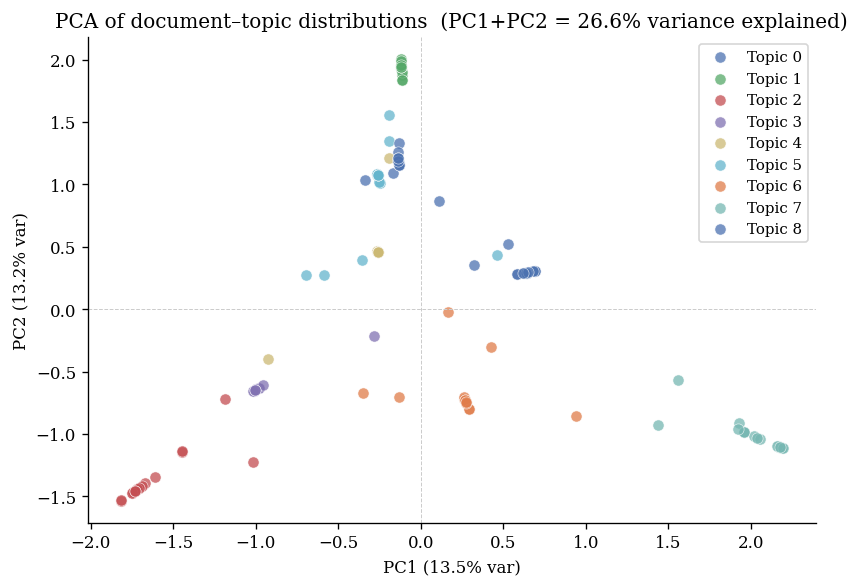

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA on the document-topic probability matrix
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(global_doc_topic)

pca    = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X_scaled)

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

plot_df       = df.copy()
plot_df['PC1'] = coords[:, 0]
plot_df['PC2'] = coords[:, 1]

topic_palette = ['#4C72B0', '#55A868', '#C44E52', '#8172B2',
                 '#CCB974', '#64B5CD', '#E07C4A', '#76B7B2']

fig, ax = plt.subplots(figsize=(7, 5))

for t in sorted(plot_df['global_topic'].unique()):
    mask = plot_df['global_topic'] == t
    ax.scatter(plot_df.loc[mask, 'PC1'],
               plot_df.loc[mask, 'PC2'],
               c=topic_palette[t % len(topic_palette)],
               label=f'Topic {t}', alpha=0.75, s=45,
               edgecolors='white', linewidths=0.4)


ax.axhline(0, color='#cccccc', linewidth=0.6, linestyle='--')
ax.axvline(0, color='#cccccc', linewidth=0.6, linestyle='--')
ax.set_xlabel(f'PC1 ({pc1_var:.1f}% var)')
ax.set_ylabel(f'PC2 ({pc2_var:.1f}% var)')
ax.set_title(f'PCA of document–topic distributions  '
             f'(PC1+PC2 = {pc1_var+pc2_var:.1f}% variance explained)')
ax.legend(fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig('fig_topic_pca.png', bbox_inches='tight')
plt.show()

### pyLDAvis for each window — see how topics shift over time

We now run pyLDAvis on each window's documents independently, so you can
see which terms are most characteristic of each time period.

A window where all topics are crammed together indicates low topical diversity
(the team was focused on one thing). Spread-out topics indicate a window with
multiple parallel work streams.

In [12]:
import pyLDAvis
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()

for w in sorted(df['window'].unique()):
    w_texts = df[df['window'] == w]['text'].fillna('').astype(str).tolist()
    X_w = vectorizer.transform(w_texts)
    n_topics_w = max(2, min(N_GLOBAL_TOPICS, len(w_texts)))

    lda_w = LatentDirichletAllocation(
        n_components=n_topics_w, random_state=SEED,
        max_iter=30, learning_method='batch'
    )
    lda_w.fit(X_w)

    vis_data = pyLDAvis.lda_model.prepare(
        lda_w, X_w, vectorizer,
        mds='tsne', sort_topics=False
    )
    display(pyLDAvis.display(vis_data))

## 2. Temporal network construction

We model the interaction corpus as a **directed temporal multigraph**:
- **Nodes** = unique actors (human teammates + `AI` as an aggregate node)
- **Edges** = one per interaction, carrying window, task type, reach type, topic, and sentiment

We then collapse edges into per-window snapshots and compute centrality metrics for each node at each window.

In [28]:
G = nx.MultiDiGraph()
G.graph['name'] = 'LLM Hackathon Temporal Interaction Network'

all_senders   = df['sender'].unique()
all_receivers = df['receiver'].unique()
all_actors    = (set(all_senders) | set(all_receivers)) - {'unknown'}

AI_KEYWORDS = ["copilot", "chatgpt", "gpt", "gemini", "claude", "github"]

def is_ai(name):
    n = str(name).lower()
    return any(k in n for k in AI_KEYWORDS)

human_actors = sorted([a for a in all_actors if not is_ai(a)])
anon_labels  = [f'{chr(65 + i)}1' for i in range(len(human_actors))]  # anonomize data
anon_map     = dict(zip(human_actors, anon_labels))

def anonymise(name):
    return anon_map.get(name, name)

for actor in all_actors:
    node_str = actor.lower()
    if "copilot" in node_str:
        n_type = "copilot"
    elif "chatgpt" in node_str or "gpt" in node_str:
        n_type = "chatgpt"
    elif "gemini" in node_str:
        n_type = "gemini"
    elif "claude" in node_str:
        n_type = "claude"
    else:
        n_type = "human"
    G.add_node(anonymise(actor), node_type=n_type)

for _, row in df.iterrows():
    src = anonymise(row['sender'])
    tgt = anonymise(row['receiver'])
    if 'unknown' in (src, tgt):
        continue
    G.add_edge(src, tgt,
               window=int(row['window']),
               idx=int(row['idx']),
               task_type=row['task_type'],
               reach_type=row['reach_type'],
               global_topic=int(row['global_topic']),
               sentiment_score=float(row['sentiment_score']),
               sentiment_label=row['sentiment_label'])

In [29]:
# Build per-window snapshots and compute centrality metrics
windows    = sorted(df['window'].unique())
snapshots  = {}
node_rows  = []

for w in windows:
    snap = nx.DiGraph()
    snap.add_nodes_from(G.nodes(data=True))
    for u, v, data in G.edges(data=True):
        if data['window'] == w:
            if snap.has_edge(u, v):
                snap[u][v]['weight'] += 1
            else:
                snap.add_edge(u, v, weight=1)
    snapshots[w] = snap

    if snap.number_of_edges() == 0:
        continue

    deg_cent = nx.degree_centrality(snap)
    try:
        bet_cent = nx.betweenness_centrality(snap, weight='weight', normalized=True)
    except Exception:
        bet_cent = {n: 0.0 for n in snap.nodes()}

    for node in snap.nodes():
        node_rows.append({
            'window': w, 'node': node,
            'node_type': G.nodes[node].get('node_type','human'),
            'degree_centrality':      round(deg_cent.get(node, 0.0), 4),
            'betweenness_centrality': round(bet_cent.get(node, 0.0), 4),
            'out_degree': snap.out_degree(node),
            'in_degree':  snap.in_degree(node),
        })

node_metrics = pd.DataFrame(node_rows)

### Network snapshots — one panel per window

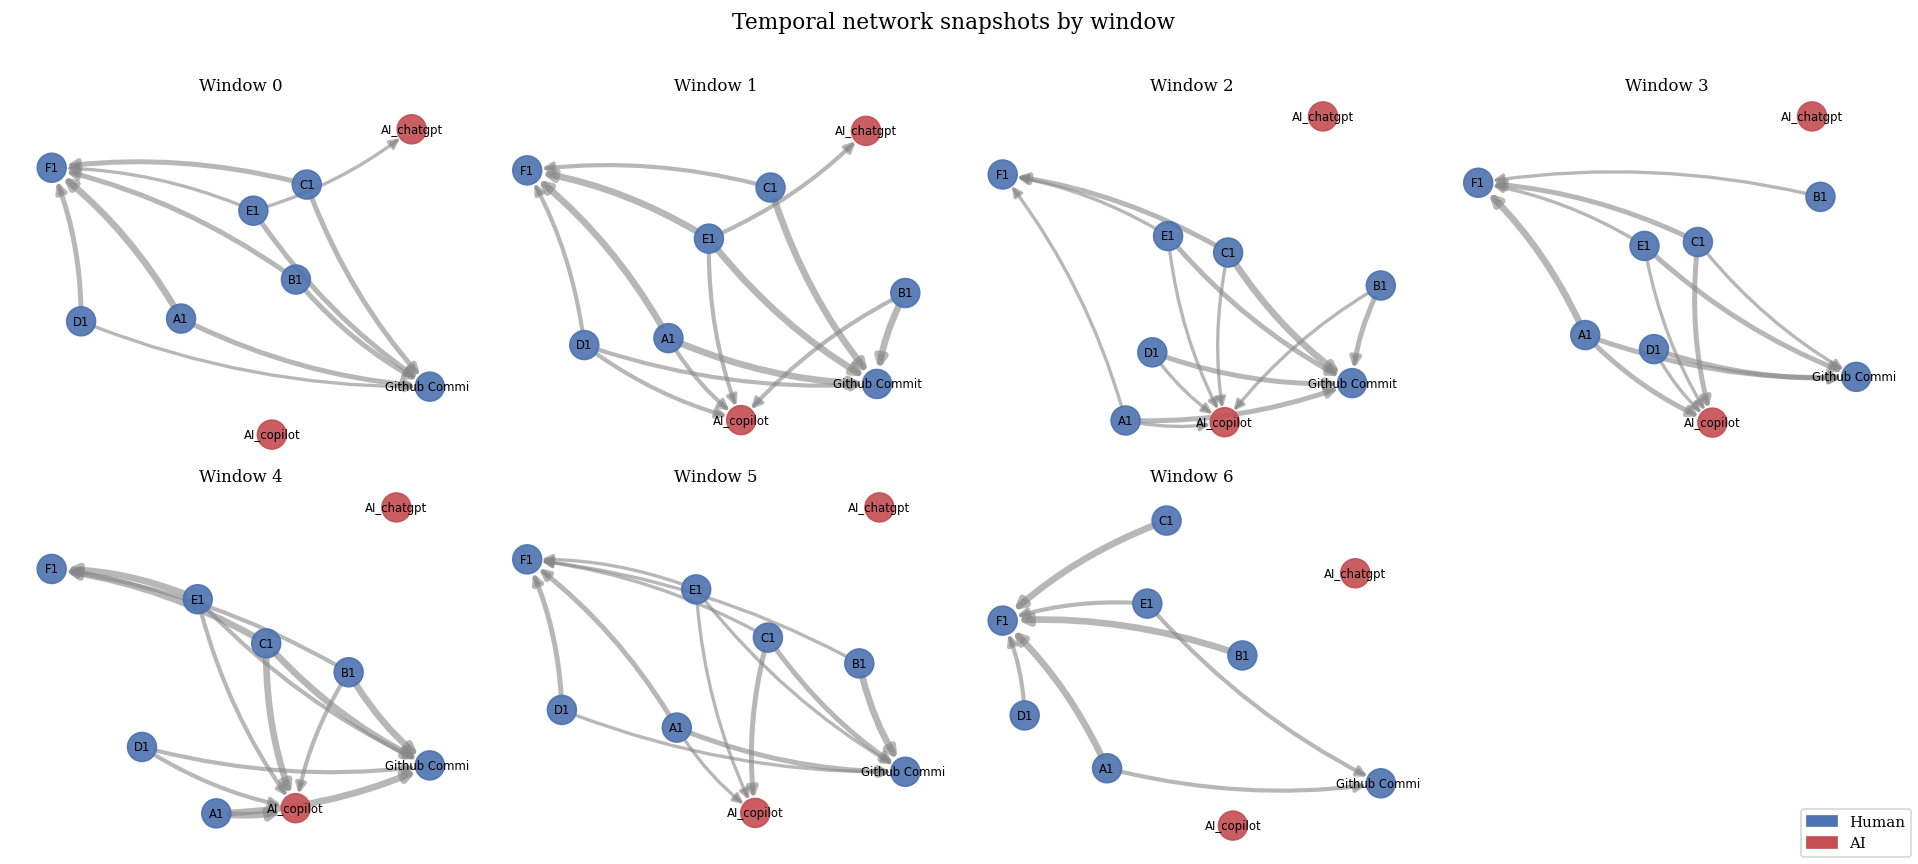

In [30]:
ncols = min(4, len(windows))
nrows = (len(windows) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
axes = np.array(axes).flatten()

for ax, w in zip(axes, windows):
    snap = snapshots[w]
    pos  = nx.spring_layout(snap, seed=SEED, k=1.8)
    node_cols = ['#C44E52' if 'AI' in n else '#4C72B0' for n in snap.nodes()]
    weights   = [snap[u][v].get('weight',1) for u,v in snap.edges()]
    max_w     = max(weights) if weights else 1
    widths    = [1 + 3*(wt/max_w) for wt in weights]
    nx.draw_networkx_nodes(snap, pos, ax=ax, node_size=300, node_color=node_cols, alpha=0.9)
    nx.draw_networkx_labels(snap, pos, ax=ax, font_size=7)
    nx.draw_networkx_edges(snap, pos, ax=ax, width=widths, edge_color='#888', alpha=0.6,
                           arrows=True, arrowsize=12, connectionstyle='arc3,rad=0.1')
    ax.set_title(f'Window {w}', fontsize=10)
    ax.axis('off')

for ax in axes[len(windows):]:
    ax.set_visible(False)

human_p = mpatches.Patch(color='#4C72B0', label='Human')
ai_p    = mpatches.Patch(color='#C44E52', label='AI')
fig.legend(handles=[human_p, ai_p], loc='lower right', fontsize=9)
fig.suptitle('Temporal network snapshots by window', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_network_snapshots.png', bbox_inches='tight')
plt.show()

## 3. Transition matrices

Visualise the global topic transition across the windows through a heatmap.

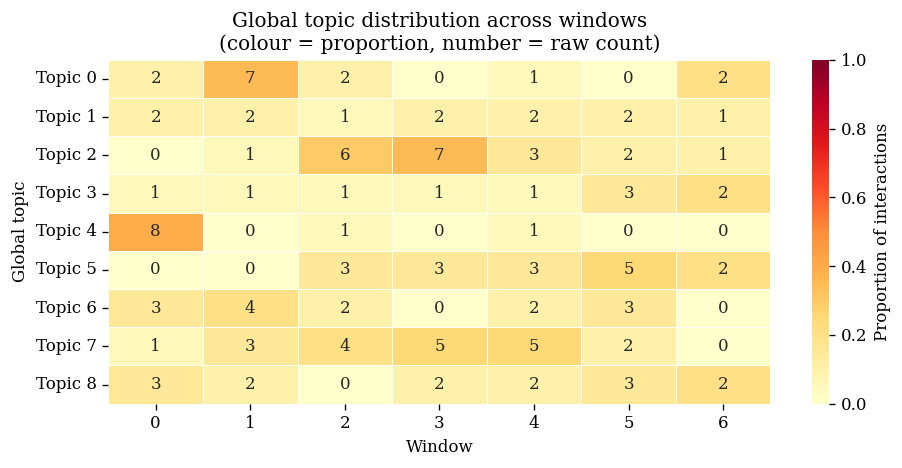

In [31]:
topic_window = (
    df.groupby(['window', 'global_topic'])
      .size()
      .unstack(fill_value=0)
)

topic_window_norm = topic_window.div(topic_window.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(
    topic_window_norm.T,          # topics as rows, windows as columns
    ax=ax,
    cmap='YlOrRd',
    annot=topic_window.T,         # annotate with raw counts
    fmt='d',
    linewidths=0.5,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Proportion of interactions'}
)

ax.set_xlabel('Window')
ax.set_ylabel('Global topic')
ax.set_title('Global topic distribution across windows\n(colour = proportion, number = raw count)')
ax.set_yticklabels([f'Topic {t}' for t in topic_window_norm.columns], rotation=0)

plt.tight_layout()
plt.savefig('fig_topic_window_heatmap.png', bbox_inches='tight')
plt.show()

## 4. Spearman rank correlation — sentiment trajectory

Test if sentiment changes over time. 

**The null hypothesis (H₀):** ρ = 0 — no monotonic relationship between time and sentiment.

In [32]:
df_sorted = df.sort_values('idx').reset_index(drop=True)

df_pos = df_sorted[df_sorted['sentiment_label'] == 'positive'].reset_index(drop=True)
df_neg = df_sorted[df_sorted['sentiment_label'] == 'negative'].reset_index(drop=True)

# Window-level means per polarity
windows = sorted(df['window'].unique())

def window_means_for(subset):
    return subset.groupby('window')['sentiment_score'].mean()

wm_pos = window_means_for(df_pos)
wm_neg = window_means_for(df_neg)

# Window-level Spearman
shared_windows_pos = [w for w in windows if w in wm_pos.index]
shared_windows_neg = [w for w in windows if w in wm_neg.index]

rho_w_pos, p_w_pos = stats.spearmanr(shared_windows_pos, [wm_pos[w] for w in shared_windows_pos])
rho_w_neg, p_w_neg = stats.spearmanr(shared_windows_neg, [wm_neg[w] for w in shared_windows_neg])

# Interaction-level Spearman
# Use the original sequential index (position in full timeline) as the time axis,
# not the within-subset index, so temporal spacing is preserved
rho_i_pos, p_i_pos = stats.spearmanr(df_pos.index, df_pos['sentiment_score'])
rho_i_neg, p_i_neg = stats.spearmanr(df_neg.index, df_neg['sentiment_score'])

print('=== Spearman rank correlation: sentiment ~ time ===')
print()
print('POSITIVE interactions')
print(f'  Window-level      (n={len(shared_windows_pos):>3}): rho = {rho_w_pos:+.3f}   p = {p_w_pos:.4f}', end='  ')
print('SIGNIFICANT' if p_w_pos < 0.05 else 'not significant')
print(f'  Interaction-level (n={len(df_pos):>3}): rho = {rho_i_pos:+.3f}   p = {p_i_pos:.4f}', end='  ')
print('SIGNIFICANT' if p_i_pos < 0.05 else 'not significant')

print()
print('NEGATIVE interactions')
print(f'  Window-level      (n={len(shared_windows_neg):>3}): rho = {rho_w_neg:+.3f}   p = {p_w_neg:.4f}', end='  ')
print('SIGNIFICANT' if p_w_neg < 0.05 else 'not significant')
print(f'  Interaction-level (n={len(df_neg):>3}): rho = {rho_i_neg:+.3f}   p = {p_i_neg:.4f}', end='  ')
print('SIGNIFICANT' if p_i_neg < 0.05 else 'not significant')

print()
for polarity, rho_w, p_w, rho_i, p_i in [
    ('Positive', rho_w_pos, p_w_pos, rho_i_pos, p_i_pos),
    ('Negative', rho_w_neg, p_w_neg, rho_i_neg, p_i_neg),
]:
    if p_w >= 0.05 and p_i >= 0.05:
        print(f'Interpretation ({polarity}): No monotonic trend — variation tied to task phase.')
    elif rho_w > 0 or rho_i > 0:
        print(f'Interpretation ({polarity}): Scores increase over time.')
    else:
        print(f'Interpretation ({polarity}): Scores decrease over time.')

=== Spearman rank correlation: sentiment ~ time ===

POSITIVE interactions
  Window-level      (n=  7): rho = +0.964   p = 0.0005  SIGNIFICANT
  Interaction-level (n=107): rho = +0.324   p = 0.0007  SIGNIFICANT

NEGATIVE interactions
  Window-level      (n=  5): rho = -1.000   p = 0.0000  SIGNIFICANT
  Interaction-level (n= 21): rho = -0.487   p = 0.0251  SIGNIFICANT

Interpretation (Positive): Scores increase over time.
Interpretation (Negative): Scores decrease over time.


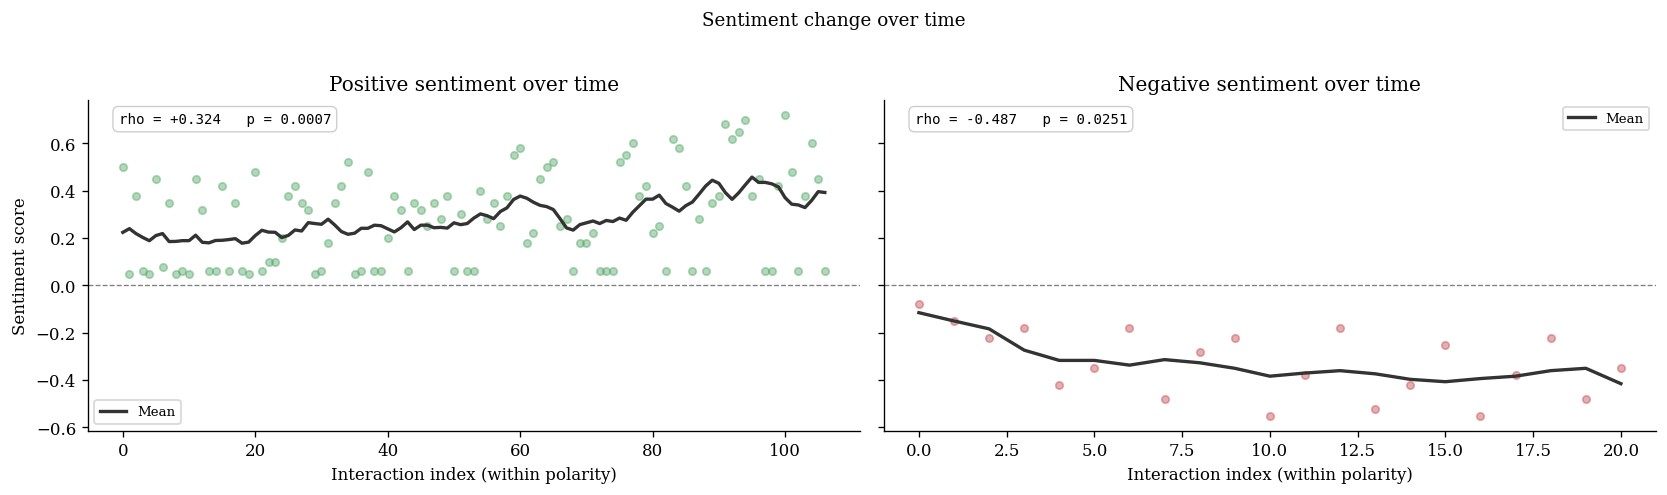

In [33]:
color_map = {'positive': '#55A868', 'neutral': '#4C72B0', 'negative': '#C44E52'}
roll_size  = max(5, len(df_sorted) // 10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, subset, label, rho_i, p_i, color in [
    (axes[0], df_pos, 'Positive',  rho_i_pos, p_i_pos, '#55A868'),
    (axes[1], df_neg, 'Negative',  rho_i_neg, p_i_neg, '#C44E52'),
]:
    ax.scatter(subset.index, subset['sentiment_score'],
               c=color, alpha=0.45, s=20, zorder=2)

    smooth = (pd.Series(subset['sentiment_score'].values)
                .rolling(max(3, len(subset) // 8), center=True, min_periods=1)
                .mean())
    ax.plot(subset.index, smooth, color='#333', linewidth=2,
            zorder=3, label='Mean')

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

    ax.annotate(f'rho = {rho_i:+.3f}   p = {p_i:.4f}',
                xy=(0.04, 0.93), xycoords='axes fraction', fontsize=8.5,
                family='monospace',
                bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#cccccc', lw=0.8))

    ax.set_title(f'{label} sentiment over time')
    ax.set_xlabel('Interaction index (within polarity)')
    ax.legend(fontsize=8, framealpha=0.8)

axes[0].set_ylabel('Sentiment score')

plt.suptitle('Sentiment change over time', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig_double_sentiment_spearman.png', bbox_inches='tight')
plt.show()

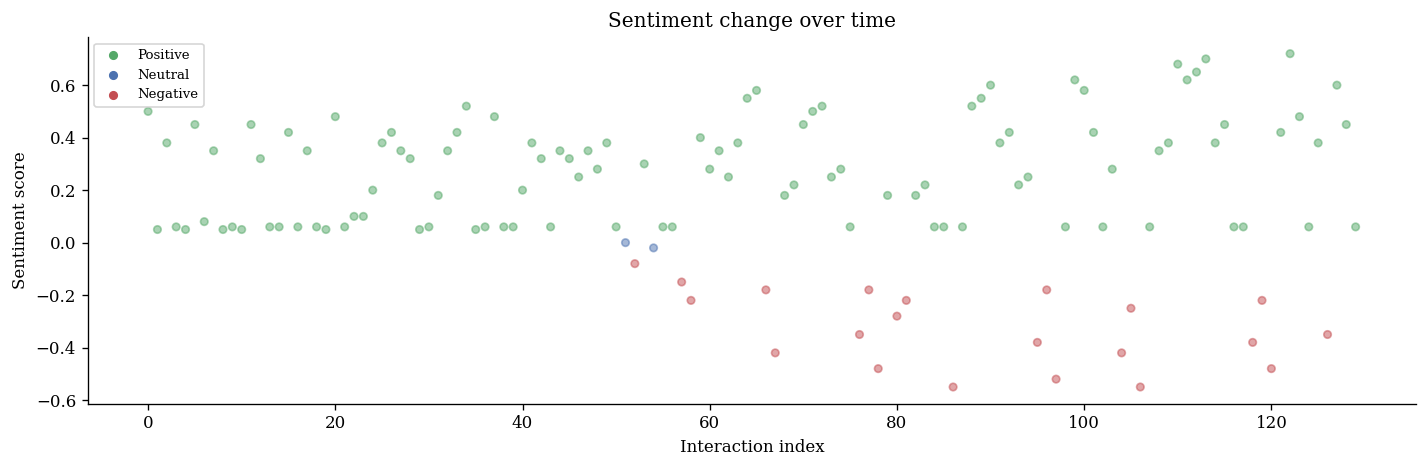

In [34]:
fig, axes = plt.subplots(1, 1, figsize=(12, 4))

color_map = {'positive':'#55A868','neutral':'#4C72B0','negative':'#C44E52'}
cols = df_sorted['sentiment_label'].map(color_map).fillna('#888')
axes.scatter(df_sorted.index, df_sorted['sentiment_score'],
            c=cols, alpha=0.5, s=20, zorder=2)
for label, col in color_map.items():
    axes.scatter([], [], c=col, label=label.capitalize(), s=20)
axes.legend(fontsize=8, framealpha=0.8)
axes.set_xlabel('Interaction index')
axes.set_ylabel('Sentiment score')
axes.set_title('Sentiment change over time')

plt.tight_layout()
plt.savefig('fig_sentiment_spearman.png', bbox_inches='tight')
plt.show()